# Pengolahan & Analisis Citra Digital
### *Pembuktian Matriks Piksel Citra & Ekstraksi Metadata EXIF*




## 1. Memuat Citra Digital & Eksplorasi Matriks Piksel 


In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Tentukan jalur file citra
img_path = os.path.join("images", "img.jpg")

# 2. Memuat citra dengan PIL
img_raw = Image.open(img_path)

# 3. Konversi citra ke matriks numerik NumPy Array
img_array = np.array(img_raw)

# 4. Ekstraksi properti dasar matriks citra
height, width, channels = img_array.shape
total_pixels = height * width
data_type = img_array.dtype
file_size_mb = os.path.getsize(img_path) / (1024 * 1024)

print("=" * 55)
print("       INFORMASI REPRESENTASI MATRIKS CITRA DIGITAL")
print("=" * 55)
print(f"Ukuran File         : {file_size_mb:.2f} MB")
print(f"Dimensi Citra (H x W): {height} x {width} piksel")
print(f"Jumlah Kanal Warna   : {channels} (Red, Green, Blue)")
print(f"Total Piksel         : {total_pixels:,} piksel")
print(f"Tipe Data Piksel     : {data_type} (Integer 8-bit: 0 s/d 255)")
print(f"Rentang Nilai Piksel : Min = {img_array.min()}, Max = {img_array.max()}")
print("=" * 55)

# Cetak sampel sub-matriks angka RGB (3x3 piksel dari pojok kiri atas)
print("\n[BUKTI MATRIKS] Sampel Nilai Angka RGB (3x3 Piksel Pertama):")
print(img_array[0:3, 0:3, :])


       INFORMASI REPRESENTASI MATRIKS CITRA DIGITAL
Ukuran File         : 4.32 MB
Dimensi Citra (H x W): 3060 x 4080 piksel
Jumlah Kanal Warna   : 3 (Red, Green, Blue)
Total Piksel         : 12,484,800 piksel
Tipe Data Piksel     : uint8 (Integer 8-bit: 0 s/d 255)
Rentang Nilai Piksel : Min = 0, Max = 255

[BUKTI MATRIKS] Sampel Nilai Angka RGB (3x3 Piksel Pertama):
[[[120 116 117]
  [113 109 110]
  [118 114 115]]

 [[121 117 118]
  [119 115 116]
  [117 113 114]]

 [[117 113 114]
  [119 115 116]
  [116 114 115]]]


---  
## 2. Pembuktian Komputasional: Citra Digital = Sekumpulan Angka yang Diproses Komputer

Untuk membuktikan klaim utama project, kita melakukan 2 pengujian langsung:
1. **Inspeksi Matriks Lokal ROI (*Region of Interest*)**: Melihat angka asli RGB pada $5 \times 5$ piksel di titik tengah citra.
2. **Manipulasi Angka Matriks $\rightarrow$ Perubahan Visual Citra**: Melakukan operasi matematika langsung terhadap matriks piksel dan membuktikan bahwa perubahan angka secara langsung mengubah wujud visual gambar.


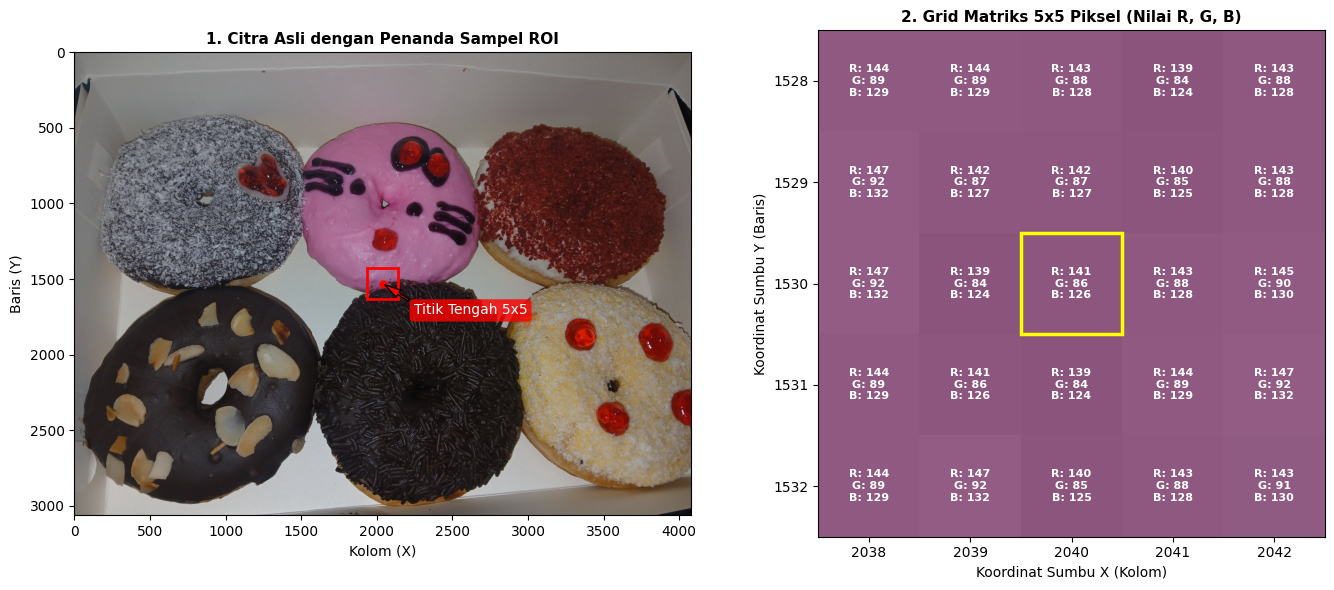

In [12]:
# 1. Menentukan Koordinat Pusat (ROI)
cy, cx = height // 2, width // 2
roi_size = 5
half = roi_size // 2

# Potong matriks 5x5 piksel
sub_matrix = img_array[cy - half : cy + half + 1, cx - half : cx + half + 1]

# Visualisasi Panel Ganda (Foto Utuh vs Zoom Matriks 5x5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel Kiri: Citra Asli + Penanda ROI
ax1.imshow(img_array)
ax1.set_title("1. Citra Asli dengan Penanda Sampel ROI", fontsize=11, fontweight="bold")
box_w = min(width, height) // 15
rect = plt.Rectangle((cx - box_w // 2, cy - box_w // 2), box_w, box_w, edgecolor="red", facecolor="none", linewidth=2)
ax1.add_patch(rect)
ax1.plot(cx, cy, "ro", markersize=5)
ax1.annotate("Titik Tengah 5x5", xy=(cx, cy), xytext=(cx + box_w, cy + box_w),
             arrowprops=dict(facecolor="red", shrink=0.05, width=1.5, headwidth=6),
             color="white", bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="none", alpha=0.8))
ax1.set_xlabel("Kolom (X)")
ax1.set_ylabel("Baris (Y)")

# Panel Kanan: Zoom Matriks 5x5 + Teks Angka RGB
ax2.imshow(sub_matrix)
ax2.set_title("2. Grid Matriks 5x5 Piksel (Nilai R, G, B)", fontsize=11, fontweight="bold")

for i in range(roi_size):
    for j in range(roi_size):
        r, g, b = sub_matrix[i, j]
        # Pilih warna teks kontras berdasarkan tingkat kecerahan piksel
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        txt_color = "white" if luminance < 128 else "black"
        ax2.text(j, i, f"R: {r}\nG: {g}\nB: {b}", ha="center", va="center", color=txt_color, fontsize=8, fontweight="bold")

# Tandai piksel pusat (indeks 2,2)
center_rect = plt.Rectangle((half - 0.5, half - 0.5), 1, 1, edgecolor="yellow", facecolor="none", linewidth=2.5)
ax2.add_patch(center_rect)
ax2.set_xticks(range(roi_size), [cx + k for k in range(-half, half + 1)])
ax2.set_yticks(range(roi_size), [cy + k for k in range(-half, half + 1)])
ax2.set_xlabel("Koordinat Sumbu X (Kolom)")
ax2.set_ylabel("Koordinat Sumbu Y (Baris)")

plt.tight_layout()
roi_fig_path = os.path.join("images", "sampel_piksel_roi.png")
plt.savefig(roi_fig_path, dpi=150, bbox_inches="tight")
plt.show()


### 💡 Penjelasan Visualisasi ROI
Pada panel kanan di atas, setiap kotak mewakili **satu piksel fisik** di layar. Tiga baris angka di dalam kotak tersebut secara berurutan adalah nilai intensitas warna **Red**, **Green**, dan **Blue** (rentang 0-255). Piksel yang ditandai kotak kuning adalah titik pusat $(X, Y)$ dari lokasi foto utuh di panel kiri.


In [ ]:
# -----------------------------------------------------
# BUKTI OPERASI MATEMATIKA KOMPUTER PADA MATRIKS CITRA
# -----------------------------------------------------

# Operasi 1: Kecerahan (Penambahan Skalar +60, dipatok maks 255)
img_bright = np.clip(img_array.astype(np.int16) + 60, 0, 255).astype(np.uint8)

# Operasi 2: Inversi Warna (Negatif Citra: 255 - I)
img_invert = 255 - img_array

# Operasi 3: Konversi Grayscale (Bobot Luminance: Y = 0.299R + 0.587G + 0.114B)
img_gray = np.dot(img_array[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# Operasi 4: Binarisasi / Thresholding (Jika Y > 128 -> 255, else -> 0)
img_binary = np.where(img_gray > 128, 255, 0).astype(np.uint8)

# Plot 4 Hasil Operasi Komputasi Angka
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_bright)
axes[0, 0].set_title("A. Brightness (+60 pada Matriks)", fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_invert)
axes[0, 1].set_title("B. Inversi Warna (255 - Matriks)", fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(img_gray, cmap="gray")
axes[1, 0].set_title("C. Grayscale (Dot Product Bobot RGB)", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_binary, cmap="gray")
axes[1, 1].set_title("D. Thresholding Biner (Logika Conditional > 128)", fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
manipulation_fig_path = os.path.join("images", "bukti_manipulasi_angka.png")
plt.savefig(manipulation_fig_path, dpi=150, bbox_inches="tight")
plt.show()


---  
## 3. Analisis & Dekomposisi Kanal Warna (RGB)
Memisah matriks 3D menjadi 3 matriks 2D independen ($R, G, B$) untuk menganalisis statistik nilai piksel masing-masing warna.


In [4]:
# Pemisahan 3 Kanal Matriks 2D
ch_red = img_array[:, :, 0]
ch_green = img_array[:, :, 1]
ch_blue = img_array[:, :, 2]

# Hitung statistik matematis tiap kanal
stats = {
    "Red": {"min": ch_red.min(), "max": ch_red.max(), "mean": ch_red.mean(), "std": ch_red.std()},
    "Green": {"min": ch_green.min(), "max": ch_green.max(), "mean": ch_green.mean(), "std": ch_green.std()},
    "Blue": {"min": ch_blue.min(), "max": ch_blue.max(), "mean": ch_blue.mean(), "std": ch_blue.std()},
}

print("=" * 60)
print("         STATISTIK METRIK INTENSITAS KANAL WARNA")
print("=" * 60)
print(f"{'Kanal':<8} | {'Min':<5} | {'Max':<5} | {'Rata-rata (Mean)':<18} | {'Standar Deviasi':<15}")
print("-" * 60)
for name, s in stats.items():
    print(f"{name:<8} | {s['min']:<5} | {s['max']:<5} | {s['mean']:<18.2f} | {s['std']:<15.2f}")
print("=" * 60)

# Menentukan kanal warna paling dominan
dominant_channel = max(stats, key=lambda k: stats[k]["mean"])
print(f"Kanal Warna Dominan berdasarkan Rata-rata Intensitas: {dominant_channel}")


         STATISTIK METRIK INTENSITAS KANAL WARNA
Kanal    | Min   | Max   | Rata-rata (Mean)   | Standar Deviasi
------------------------------------------------------------
Red      | 0     | 255   | 106.02             | 50.20          
Green    | 0     | 255   | 91.01              | 52.20          
Blue     | 0     | 255   | 89.50              | 52.59          
Kanal Warna Dominan berdasarkan Rata-rata Intensitas: Red


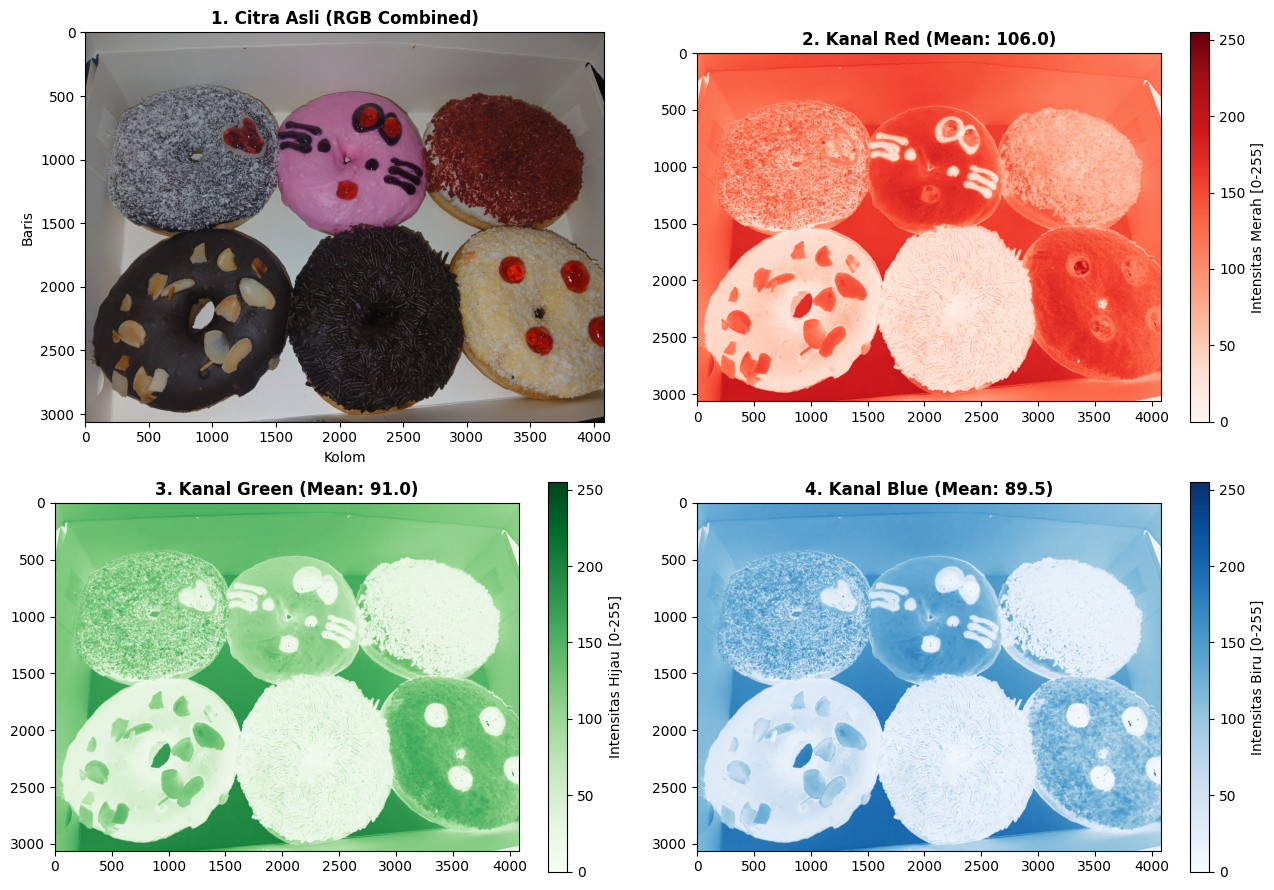

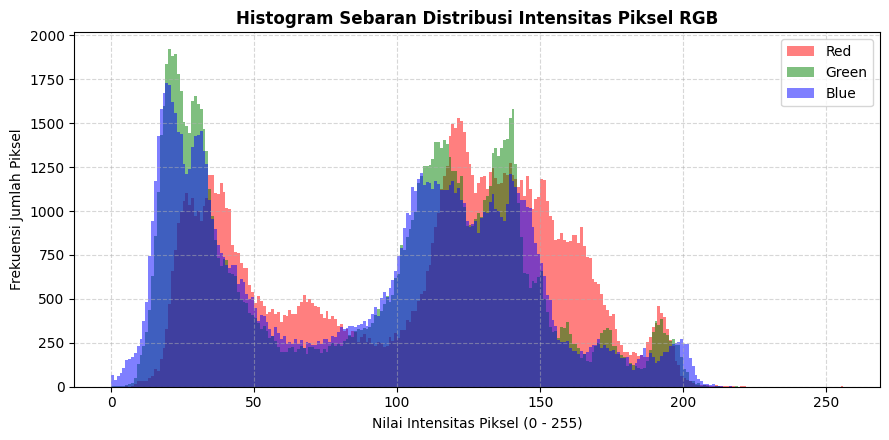

In [8]:
# 1. Visualisasi Dekomposisi 3 Kanal Warna dengan Colorbar Intensitas
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].imshow(img_array)
axes[0, 0].set_title("1. Citra Asli (RGB Combined)", fontweight="bold")
axes[0, 0].set_xlabel("Kolom")
axes[0, 0].set_ylabel("Baris")

im_r = axes[0, 1].imshow(ch_red, cmap="Reds")
axes[0, 1].set_title(f"2. Kanal Red (Mean: {ch_red.mean():.1f})", fontweight="bold")
fig.colorbar(im_r, ax=axes[0, 1], label="Intensitas Merah [0-255]")

im_g = axes[1, 0].imshow(ch_green, cmap="Greens")
axes[1, 0].set_title(f"3. Kanal Green (Mean: {ch_green.mean():.1f})", fontweight="bold")
fig.colorbar(im_g, ax=axes[1, 0], label="Intensitas Hijau [0-255]")

im_b = axes[1, 1].imshow(ch_blue, cmap="Blues")
axes[1, 1].set_title(f"4. Kanal Blue (Mean: {ch_blue.mean():.1f})", fontweight="bold")
fig.colorbar(im_b, ax=axes[1, 1], label="Intensitas Biru [0-255]")

plt.tight_layout()
decomp_fig_path = os.path.join("images", "dekomposisi_rgb.png")
plt.savefig(decomp_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# 2. Grafik Histogram Distribusi Intensitas RGB
plt.figure(figsize=(9, 4.5))
plt.title("Histogram Sebaran Distribusi Intensitas Piksel RGB", fontweight="bold")

# Subsampling piksel (tiap piksel ke-10) untuk efisiensi render
plt.hist(ch_red[::10, ::10].ravel(), bins=256, range=(0, 256), color="red", alpha=0.5, label="Red")
plt.hist(ch_green[::10, ::10].ravel(), bins=256, range=(0, 256), color="green", alpha=0.5, label="Green")
plt.hist(ch_blue[::10, ::10].ravel(), bins=256, range=(0, 256), color="blue", alpha=0.5, label="Blue")

plt.xlabel("Nilai Intensitas Piksel (0 - 255)")
plt.ylabel("Frekuensi Jumlah Piksel")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
hist_fig_path = os.path.join("images", "histogram_rgb.png")
plt.savefig(hist_fig_path, dpi=150, bbox_inches="tight")
plt.show()



- **Dekomposisi Kanal**: Menampilkan visualisasi tingkat intensitas masing-masing kanal warna secara independen. Area dengan warna pekat pada skala warna merepresentasikan nilai intensitas yang tinggi.
- **Histogram RGB**: Menggambarkan sebaran frekuensi nilai piksel $0-255$. Puncak grafik menunjukkan tingkat kecerahan yang mendominasi gambar.


---  
## 4. Ekstraksi Metadata EXIF Terkategori (5 Kategori )

Metadata EXIF (*Exchangeable Image File Format*) direkam oleh perangkat saat foto diambil. Pada bagian ini, kita mengelompokkan metadata ke dalam **5 Kategori Utama**:
1. **Identitas Perangkat** (*Device Identity*)
2. **Informasi Waktu** (*Time Information*)
3. **Informasi Teknis Kamera** (*Camera Technical Information*)
4. **Informasi Lokasi** (*Location / GPS Information*)
5. **Informasi Pengolahan** (*Processing & Digital Image Parameters*)


In [6]:
from PIL import ExifTags
from PIL.ExifTags import TAGS, GPSTAGS, IFD

def helper_rasional(val, satuan=""):
    """Konversi pecahan EXIF ke format desimal terbaca."""
    try:
        v = float(val)
        return f"{v:g}{satuan}"
    except Exception:
        return "-"

def helper_shutter(val):
    """Konversi waktu eksposur ke pecahan detik (misal 1/50 s)."""
    try:
        v = float(val)
        if 0 < v < 1:
            return f"1/{round(1/v)} s"
        return f"{v:g} s"
    except Exception:
        return "-"

def helper_dms_to_decimal(coords, ref):
    """Konversi koordinat GPS Derajat, Menit, Detik ke Desimal."""
    try:
        d, m, s = [float(x) for x in coords]
        dec = d + (m / 60.0) + (s / 3600.0)
        if ref in ["S", "W"]:
            dec = -dec
        return dec
    except Exception:
        return None

def ekstrak_exif_5_kategori(image_path):
    """Mengekstrak dan mengelompokkan data EXIF ke dalam 5 kategori terstruktur."""
    img = Image.open(image_path)
    raw_exif = img.getexif()
    
    all_tags = {}
    # Ambil tag dari main EXIF
    for tag_id, val in raw_exif.items():
        all_tags[TAGS.get(tag_id, tag_id)] = val
        
    # Ambil sub-IFD
    for ifd_id in [IFD.Exif, IFD.IFD1, IFD.Interop, IFD.GPSInfo]:
        try:
            sub = raw_exif.get_ifd(ifd_id)
            for tag_id, val in sub.items():
                name = GPSTAGS.get(tag_id, TAGS.get(tag_id, tag_id)) if ifd_id == IFD.GPSInfo else TAGS.get(tag_id, tag_id)
                all_tags[name] = val
        except Exception:
            pass

    # 1. Kategori Identitas Perangkat
    kat_1_perangkat = {
        "Merek Kamera / HP (Make)": all_tags.get("Make", "-"),
        "Model Perangkat (Model)": all_tags.get("Model", "-"),
        "Perangkat Lunak / Software": all_tags.get("Software", "-"),
        "Model Lensa / Serial": all_tags.get("LensModel", all_tags.get("BodySerialNumber", "-")),
    }

    # 2. Kategori Informasi Waktu
    kat_2_waktu = {
        "Waktu Asli Foto (DateTimeOriginal)": all_tags.get("DateTimeOriginal", "-"),
        "Waktu Digitalisasi (DateTimeDigitized)": all_tags.get("DateTimeDigitized", "-"),
        "Waktu Berkas (DateTime)": all_tags.get("DateTime", "-"),
        "Sub-Detik (SubsecTimeOriginal)": all_tags.get("SubsecTimeOriginal", "-"),
        "Zona Waktu Offset": all_tags.get("OffsetTimeOriginal", all_tags.get("OffsetTime", "-")),
    }

    # 3. Kategori Informasi Teknis Kamera
    kat_3_teknis = {
        "Waktu Eksposur / Shutter Speed": helper_shutter(all_tags.get("ExposureTime")),
        "Bukaan Diafragma (Aperture/FNumber)": f"f/{helper_rasional(all_tags.get('FNumber'))}" if all_tags.get('FNumber') else "-",
        "Sensitivitas Sensor (ISO)": all_tags.get("ISOSpeedRatings", all_tags.get("PhotographicSensitivity", "-")),
        "Panjang Fokus Lensa (Focal Length)": helper_rasional(all_tags.get("FocalLength"), " mm"),
        "Ekuivalen Lensa 35mm": helper_rasional(all_tags.get("FocalLengthIn35mmFilm"), " mm"),
        "Program Eksposur": all_tags.get("ExposureProgram", "-"),
        "Mode Pengukuran Cahaya (Metering)": all_tags.get("MeteringMode", "-"),
        "Status Flash": all_tags.get("Flash", "-"),
        "Keseimbangan Putih (White Balance)": all_tags.get("WhiteBalance", "-"),
        "Exposure Bias Value": helper_rasional(all_tags.get("ExposureBiasValue")),
    }

    # 4. Kategori Informasi Lokasi (GPS)
    lat_raw = all_tags.get("GPSLatitude")
    lat_ref = all_tags.get("GPSLatitudeRef", "N")
    lon_raw = all_tags.get("GPSLongitude")
    lon_ref = all_tags.get("GPSLongitudeRef", "E")
    alt_raw = all_tags.get("GPSAltitude")
    
    lat_dec = helper_dms_to_decimal(lat_raw, lat_ref) if lat_raw else None
    lon_dec = helper_dms_to_decimal(lon_raw, lon_ref) if lon_raw else None
    
    kat_4_lokasi = {
        "Status GPS Data": "Tersedia" if (lat_dec and lon_dec) else "Tidak Tersedia / Di-nonaktifkan",
        "Latitude Desimal": f"{lat_dec:.6f}" if lat_dec else "-",
        "Longitude Desimal": f"{lon_dec:.6f}" if lon_dec else "-",
        "Ketinggian (Altitude)": helper_rasional(alt_raw, " meter") if alt_raw else "-",
        "Link Google Maps": f"https://www.google.com/maps?q={lat_dec},{lon_dec}" if (lat_dec and lon_dec) else "-",
    }

    # 5. Kategori Informasi Pengolahan Citra Digital
    kat_5_pengolahan = {
        "Dimensi Piksel (Width x Height)": f"{all_tags.get('ExifImageWidth', img.width)} x {all_tags.get('ExifImageHeight', img.height)} px",
        "Ruang Warna (Color Space)": "sRGB" if all_tags.get("ColorSpace") == 1 else str(all_tags.get("ColorSpace", img.mode)),
        "Kedalaman Bit (Bit Depth)": f"{img.mode} (8-bit per kanal)",
        "Resolusi X & Y": f"{all_tags.get('XResolution', '-')} x {all_tags.get('YResolution', '-')} (Unit: {all_tags.get('ResolutionUnit', '-')})",
        "Orientasi Foto": all_tags.get("Orientation", "-"),
        "Kompresi Format": img.format,
    }

    return {
        "1. Identitas Perangkat": kat_1_perangkat,
        "2. Informasi Waktu": kat_2_waktu,
        "3. Informasi Teknis Kamera": kat_3_teknis,
        "4. Informasi Lokasi": kat_4_lokasi,
        "5. Informasi Pengolahan": kat_5_pengolahan,
    }

# Jalankan Ekstraksi 5 Kategori
exif_5_kategori = ekstrak_exif_5_kategori(img_path)


In [7]:
# Cetak Tampilan Ringkasan Kartu 5 Kategori EXIF
print("=" * 65)
print("        EKSTRAKSI METADATA EXIF TERKATEGORI (5 KATEGORI)")
print("=" * 65)

for kategori, data in exif_5_kategori.items():
    print(f"\n>>> [{kategori.upper()}]")
    print("-" * 65)
    for kunci, nilai in data.items():
        print(f"  * {kunci:<38}: {nilai}")

print("\n" + "=" * 65)


        EKSTRAKSI METADATA EXIF TERKATEGORI (5 KATEGORI)

>>> [1. IDENTITAS PERANGKAT]
-----------------------------------------------------------------
  * Merek Kamera / HP (Make)              : samsung                        
  * Model Perangkat (Model)               : Galaxy A15                     
  * Perangkat Lunak / Software            : MediaTek Camera Application    
  * Model Lensa / Serial                  : -

>>> [2. INFORMASI WAKTU]
-----------------------------------------------------------------
  * Waktu Asli Foto (DateTimeOriginal)    : 2026:03:05 14:11:17
  * Waktu Digitalisasi (DateTimeDigitized): 2026:03:05 14:11:17
  * Waktu Berkas (DateTime)               : 2026:03:05 14:11:17
  * Sub-Detik (SubsecTimeOriginal)        : 997
  * Zona Waktu Offset                     : -

>>> [3. INFORMASI TEKNIS KAMERA]
-----------------------------------------------------------------
  * Waktu Eksposur / Shutter Speed        : 1/50 s
  * Bukaan Diafragma (Aperture/FNumber)   : 

---  
## 5. Kesimpulan Project

Berdasarkan eksperimen dan analisis yang telah dilakukan pada notebook ini, dapat disimpulkan bahwa:
1. **Citra Digital Adalah Sekumpulan Angka**: Terbukti secara nyata bahwa citra visual merupakan tensor/matriks numerik berukuran $\text{Tinggi} \times \text{Lebar} \times \text{Kanal}$. Setiap piksel direpresentasikan oleh nilai integer 8-bit $[0 - 255]$.
2. **Pemrosesan Komputer Merupakan Operasi Matematika**: Perubahan visual citra (seperti pencahayaan, inversi warna, konversi grayscale, dan binarisasi) terjadi akibat komputer mengeksekusi operasi matematika pada matriks angka citra.
3. **Metadata EXIF Terkategori**: Berhasil diekstraksi dan dikelompokkan secara terstruktur ke dalam 5 Kategori Utama (*Identitas Perangkat, Informasi Waktu, Informasi Teknis Kamera, Informasi Lokasi, dan Informasi Pengolahan*).
